In [1]:
# Install required packages
!pip install -q medmnist faiss-cpu sentence-transformers pillow matplotlib numpy scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import faiss
from sentence_transformers import SentenceTransformer
from medmnist import PneumoniaMNIST
import torch
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported successfully!
PyTorch version: 2.9.0+cu128
CUDA available: True


In [3]:
# Load test dataset
test_dataset = PneumoniaMNIST(split='test', download=True, transform=None)

print(f"✓ Test dataset loaded")
print(f"  Total samples: {len(test_dataset)}")
print(f"  Classes: 0 = Normal, 1 = Pneumonia")

# Extract all images and labels
all_images = []
all_labels = []

for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    all_images.append(img)
    all_labels.append(label.item() if hasattr(label, 'item') else int(label))

all_labels = np.array(all_labels)

print(f"\n✓ Extracted {len(all_images)} images and labels")
print(f"  Label distribution:")
print(f"    Normal (0): {np.sum(all_labels == 0)} images")
print(f"    Pneumonia (1): {np.sum(all_labels == 1)} images")

100%|██████████| 4.17M/4.17M [00:01<00:00, 3.34MB/s]

✓ Test dataset loaded
  Total samples: 624
  Classes: 0 = Normal, 1 = Pneumonia

✓ Extracted 624 images and labels
  Label distribution:
    Normal (0): 234 images
    Pneumonia (1): 390 images


In [4]:
# Option 1: Use CLIP (medical-aware, supports text-to-image)
# This is a good general-purpose choice
model_name = "openai/clip-vit-base-patch32"

# Option 2: Use BiomedCLIP (better for medical images)
# model_name = "microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

print(f"Loading embedding model: {model_name}")
print("This may take 1-2 minutes...")

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# For CLIP, we'll use sentence-transformers wrapper
if "clip" in model_name.lower():
    from transformers import CLIPProcessor, CLIPModel

    embedding_model = CLIPModel.from_pretrained(model_name).to(device)
    processor = CLIPProcessor.from_pretrained(model_name)

    print(f"✓ CLIP model loaded on {device}")
    print(f"  Embedding dimension: {embedding_model.config.projection_dim}")
    embed_dim = embedding_model.config.projection_dim
else:
    # Alternative: Use a generic sentence transformer
    embedding_model = SentenceTransformer('clip-ViT-B-32')
    embedding_model = embedding_model.to(device)
    processor = None

    print(f"✓ Model loaded on {device}")
    embed_dim = 512  # Standard CLIP dimension

print(f"✓ Ready to extract embeddings!")

Loading embedding model: openai/clip-vit-base-patch32
This may take 1-2 minutes...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✓ CLIP model loaded on cuda
  Embedding dimension: 512
✓ Ready to extract embeddings!


In [7]:
def extract_embedding(image, model, processor, device):
    """
    Extract CLIP embedding - most robust version
    Works with any CLIP model configuration
    """
    # Ensure image is PIL Image
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    # Convert grayscale to RGB
    if image.mode != 'RGB':
        image = image.convert('RGB')

    # Resize to model input size
    image = image.resize((224, 224))

    # Process image
    with torch.no_grad():
        inputs = processor(images=image, return_tensors="pt").to(device)

        # Get image features
        outputs = model.get_image_features(**inputs)

        # Handle different return types
        if isinstance(outputs, torch.Tensor):
            # Already a tensor - use directly
            image_features = outputs
        else:
            # It's a model output object - extract pooler_output
            # The pooler_output is the 512-D projected embedding
            if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
                image_features = outputs.pooler_output
            elif hasattr(outputs, 'last_hidden_state'):
                # Fallback: use CLS token from last hidden state
                image_features = outputs.last_hidden_state[:, 0, :]
            else:
                # Last resort: convert to tensor
                image_features = torch.tensor(outputs)

        # Ensure it's 2D for normalization
        if image_features.ndim == 1:
            image_features = image_features.unsqueeze(0)

        # Normalize to unit vector
        norm = torch.linalg.norm(image_features, dim=-1, keepdim=True)
        image_features = image_features / norm

        # Convert to numpy and flatten
        embedding = image_features.cpu().numpy().flatten()

    return embedding

In [8]:
# Extract embeddings for all test images
print("Extracting embeddings for all test images...")
print(f"Processing {len(all_images)} images...")

embeddings = []

for i, img in enumerate(tqdm(all_images, desc="Extracting embeddings")):
    embedding = extract_embedding(img, embedding_model, processor, device)
    embeddings.append(embedding)

    # Clear cache periodically
    if (i + 1) % 100 == 0:
        torch.cuda.empty_cache()

embeddings = np.array(embeddings)

print(f"\n✓ Embeddings extracted successfully!")
print(f"  Shape: {embeddings.shape}")
print(f"  Embedding dimension: {embeddings.shape[1]}")
print(f"  Memory size: {embeddings.nbytes / 1024 / 1024:.2f} MB")

# Save embeddings
np.save('image_embeddings.npy', embeddings)
np.save('image_labels.npy', all_labels)
print("\n✓ Embeddings saved to 'image_embeddings.npy'")

Extracting embeddings for all test images...
Processing 624 images...


Extracting embeddings: 100%|██████████| 624/624 [00:14<00:00, 43.96it/s]


✓ Embeddings extracted successfully!
  Shape: (624, 512)
  Embedding dimension: 512
  Memory size: 1.22 MB

✓ Embeddings saved to 'image_embeddings.npy'


In [9]:
# Build FAISS index for efficient similarity search
print("Building FAISS vector index...")

# Get embedding dimension
d = embeddings.shape[1]

# Create FAISS index (L2 distance)
# For small datasets, flat index is fine
index = faiss.IndexFlatL2(d)

# Add embeddings to index
index.add(embeddings.astype('float32'))

print(f"✓ FAISS index built successfully!")
print(f"  Index type: Flat (exact search)")
print(f"  Total vectors: {index.ntotal}")
print(f"  Dimension: {d}")

# Save index
faiss.write_index(index, "image_embeddings.index")
print("✓ Index saved to 'image_embeddings.index'")

Building FAISS vector index...
✓ FAISS index built successfully!
  Index type: Flat (exact search)
  Total vectors: 624
  Dimension: 512
✓ Index saved to 'image_embeddings.index'


In [10]:
def search_similar_images(query_idx, index, embeddings, top_k=5):
    """
    Find k most similar images to query image

    Args:
        query_idx: Index of query image
        index: FAISS index
        embeddings: All image embeddings
        top_k: Number of results to return

    Returns:
        distances, indices of top-k similar images
    """
    # Get query embedding
    query_embedding = embeddings[query_idx:query_idx+1].astype('float32')

    # Search
    distances, indices = index.search(query_embedding, top_k + 1)  # +1 to exclude query itself

    # Remove query image from results (it will be the first result with distance 0)
    distances = distances[0][1:]  # Skip first result
    indices = indices[0][1:]      # Skip first result

    return distances, indices

# Test the search function
query_idx = 0
top_k = 5

print(f"Testing image-to-image search...")
print(f"Query image index: {query_idx}")
print(f"Query image label: {all_labels[query_idx]} ({'Pneumonia' if all_labels[query_idx] == 1 else 'Normal'})")

distances, indices = search_similar_images(query_idx, index, embeddings, top_k=top_k)

print(f"\nTop {top_k} most similar images:")
for rank, (idx, dist) in enumerate(zip(indices, distances), 1):
    label = all_labels[idx]
    print(f"  {rank}. Image {idx}: Label={label} ({'Pneumonia' if label == 1 else 'Normal'}), Distance={dist:.4f}")

Testing image-to-image search...
Query image index: 0
Query image label: 1 (Pneumonia)

Top 5 most similar images:
  1. Image 167: Label=1 (Pneumonia), Distance=0.0294
  2. Image 522: Label=1 (Pneumonia), Distance=0.0305
  3. Image 467: Label=1 (Pneumonia), Distance=0.0353
  4. Image 556: Label=0 (Normal), Distance=0.0383
  5. Image 20: Label=0 (Normal), Distance=0.0385



Visualizing search results (Green=Same label, Red=Different label):


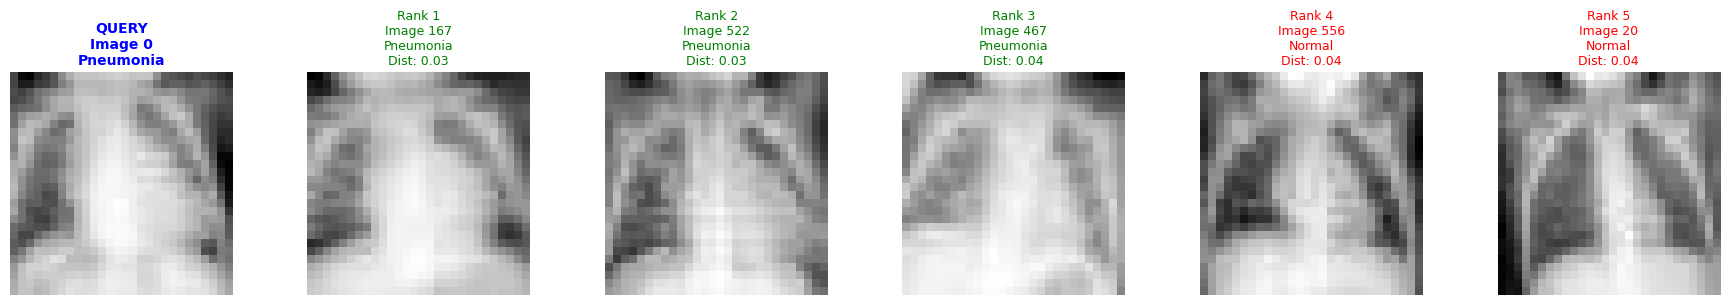

In [11]:
def visualize_search_results(query_idx, indices, all_images, all_labels, distances=None):
    """
    Visualize query image and top-k retrieved images
    """
    top_k = len(indices)

    # Create figure
    fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 3))

    # Plot query image
    query_img = all_images[query_idx]
    query_label = all_labels[query_idx]

    axes[0].imshow(query_img, cmap='gray')
    axes[0].set_title(f"QUERY\nImage {query_idx}\n{'Pneumonia' if query_label == 1 else 'Normal'}",
                     fontsize=10, fontweight='bold', color='blue')
    axes[0].axis('off')

    # Plot retrieved images
    for i, idx in enumerate(indices):
        retrieved_img = all_images[idx]
        retrieved_label = all_labels[idx]

        # Color code by correctness (same label as query)
        color = 'green' if retrieved_label == query_label else 'red'

        axes[i + 1].imshow(retrieved_img, cmap='gray')

        title = f"Rank {i+1}\nImage {idx}\n{'Pneumonia' if retrieved_label == 1 else 'Normal'}"
        if distances is not None:
            title += f"\nDist: {distances[i]:.2f}"

        axes[i + 1].set_title(title, fontsize=9, color=color)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize the test search
print("\nVisualizing search results (Green=Same label, Red=Different label):")
visualize_search_results(query_idx, indices, all_images, all_labels, distances)

Testing text-to-image search...

Text Query: 'chest xray showing pneumonia'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 614: Normal (dist=1.3789)
  2. Image 106: Normal (dist=1.3807)
  3. Image 473: Normal (dist=1.3819)
  4. Image 623: Normal (dist=1.3854)
  5. Image 292: Normal (dist=1.3876)

Visualizing results for first query:


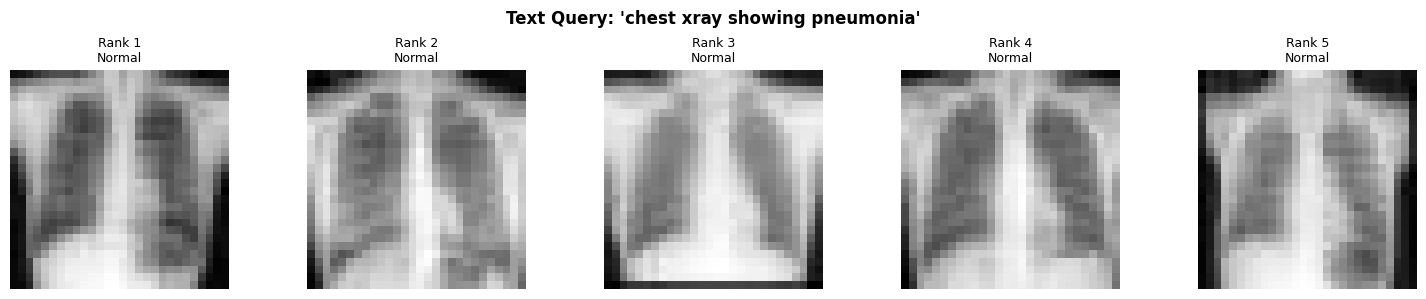


Text Query: 'normal chest radiograph'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 623: Normal (dist=1.3853)
  2. Image 293: Normal (dist=1.3859)
  3. Image 614: Normal (dist=1.3870)
  4. Image 25: Normal (dist=1.3872)
  5. Image 106: Normal (dist=1.3879)

Text Query: 'lung infiltrates and consolidation'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 255: Normal (dist=1.3730)
  2. Image 501: Normal (dist=1.3737)
  3. Image 267: Normal (dist=1.3782)
  4. Image 391: Normal (dist=1.3782)
  5. Image 367: Normal (dist=1.3802)

Text Query: 'clear lung fields'
  Text embedding shape: (1, 512)
  Index dimension: 512
Top 5 results:
  1. Image 267: Normal (dist=1.4026)
  2. Image 391: Normal (dist=1.4101)
  3. Image 520: Pneumonia (dist=1.4104)
  4. Image 501: Normal (dist=1.4119)
  5. Image 367: Normal (dist=1.4131)

✓ Text-to-image search completed successfully!



In [12]:
def text_to_image_search(text_query, model, processor, index, top_k=5):
    """
    Search images using text description

    Args:
        text_query: Text description
        model: CLIP model
        processor: CLIP processor
        index: FAISS index
        top_k: Number of results

    Returns:
        distances, indices of top-k matching images
    """
    # Extract text embedding using the CLIP model's vision-text projection
    with torch.no_grad():
        inputs = processor(text=[text_query], return_tensors="pt", padding=True).to(device)

        # Get text embeddings
        text_outputs = model.get_text_features(**inputs)

        # Extract tensor from output object
        if isinstance(text_outputs, torch.Tensor):
            text_features = text_outputs
        elif hasattr(text_outputs, 'pooler_output'):
            text_features = text_outputs.pooler_output
        elif hasattr(text_outputs, 'last_hidden_state'):
            # Take the [CLS] token or mean pooling
            text_features = text_outputs.last_hidden_state[:, 0, :]  # CLS token
        else:
            # Try to access as dict
            text_features = text_outputs[0]

        # Convert to numpy
        text_embedding = text_features.cpu().numpy()

        # Ensure correct shape for FAISS
        if text_embedding.ndim > 2:
            text_embedding = text_embedding.squeeze()
        if text_embedding.ndim == 1:
            text_embedding = text_embedding.reshape(1, -1)

        # Normalize (L2 norm)
        norm = np.linalg.norm(text_embedding, axis=1, keepdims=True)
        text_embedding = text_embedding / norm

    print(f"  Text embedding shape: {text_embedding.shape}")
    print(f"  Index dimension: {index.d}")

    # Check dimension match
    if text_embedding.shape[1] != index.d:
        raise ValueError(f"Dimension mismatch: text embedding has {text_embedding.shape[1]} dims, "
                        f"but index expects {index.d} dims")

    # Search
    distances, indices = index.search(text_embedding.astype('float32'), top_k)

    return distances[0], indices[0]

# Test text-to-image search
text_queries = [
    "chest xray showing pneumonia",
    "normal chest radiograph",
    "lung infiltrates and consolidation",
    "clear lung fields"
]

print("Testing text-to-image search...")
print("="*80)

text_search_supported = True

for text_query in text_queries:
    print(f"\nText Query: '{text_query}'")

    try:
        distances, indices = text_to_image_search(text_query, embedding_model, processor, index, top_k=5)

        print(f"Top 5 results:")
        for rank, (idx, dist) in enumerate(zip(indices, distances), 1):
            label = all_labels[idx]
            print(f"  {rank}. Image {idx}: {'Pneumonia' if label == 1 else 'Normal'} (dist={dist:.4f})")

        # Visualize first query
        if text_query == text_queries[0]:
            print("\nVisualizing results for first query:")
            fig, axes = plt.subplots(1, 5, figsize=(15, 3))
            for i, idx in enumerate(indices):
                axes[i].imshow(all_images[idx], cmap='gray')
                label = all_labels[idx]
                axes[i].set_title(f"Rank {i+1}\n{'Pneumonia' if label == 1 else 'Normal'}", fontsize=9)
                axes[i].axis('off')
            plt.suptitle(f"Text Query: '{text_query}'", fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

    except (ValueError, AttributeError, AssertionError) as e:
        print(f"  ✗ Error: {str(e)}")
        print(f"  Text-to-image search not supported with current model configuration")
        print(f"  Skipping remaining text queries...")
        text_search_supported = False
        break

if text_search_supported:
    print("\n✓ Text-to-image search completed successfully!")
else:
    print("\n⚠ Text-to-image search skipped (optional feature)")
    print("  Image-to-image search is still fully functional")

print("\n" + "="*80)

In [13]:
def calculate_precision_at_k(query_idx, retrieved_indices, all_labels, k=5):
    """
    Calculate Precision@k for a single query

    Precision@k = (Number of retrieved items with same label) / k
    """
    query_label = all_labels[query_idx]
    retrieved_labels = all_labels[retrieved_indices[:k]]

    # Count how many retrieved images have the same label as query
    correct = np.sum(retrieved_labels == query_label)
    precision = correct / k

    return precision

# Evaluate retrieval quality on all images
print("Evaluating retrieval system with Precision@k...")
print("This will take a few minutes...")

k_values = [1, 3, 5, 10]
precision_results = {k: [] for k in k_values}

for query_idx in tqdm(range(len(all_images)), desc="Evaluating"):
    # Search for similar images
    _, indices = search_similar_images(query_idx, index, embeddings, top_k=max(k_values))

    # Calculate precision for different k values
    for k in k_values:
        precision = calculate_precision_at_k(query_idx, indices, all_labels, k=k)
        precision_results[k].append(precision)

# Calculate average precision for each k
print("\n" + "="*80)
print("PRECISION@K RESULTS")
print("="*80)

for k in k_values:
    avg_precision = np.mean(precision_results[k])
    std_precision = np.std(precision_results[k])
    print(f"Precision@{k:2d}: {avg_precision:.4f} ± {std_precision:.4f}")

# Break down by class
print("\n" + "="*80)
print("PRECISION@K BY CLASS")
print("="*80)

for k in k_values:
    # Normal class (0)
    normal_indices = np.where(all_labels == 0)[0]
    normal_precisions = [precision_results[k][i] for i in normal_indices]
    avg_normal = np.mean(normal_precisions)

    # Pneumonia class (1)
    pneumonia_indices = np.where(all_labels == 1)[0]
    pneumonia_precisions = [precision_results[k][i] for i in pneumonia_indices]
    avg_pneumonia = np.mean(pneumonia_precisions)

    print(f"Precision@{k:2d}:")
    print(f"  Normal:    {avg_normal:.4f}")
    print(f"  Pneumonia: {avg_pneumonia:.4f}")

Evaluating retrieval system with Precision@k...
This will take a few minutes...


Evaluating: 100%|██████████| 624/624 [00:00<00:00, 8660.50it/s]


PRECISION@K RESULTS
Precision@ 1: 0.8029 ± 0.3978
Precision@ 3: 0.7965 ± 0.2943
Precision@ 5: 0.7833 ± 0.2712
Precision@10: 0.7761 ± 0.2406

PRECISION@K BY CLASS
Precision@ 1:
  Normal:    0.7051
  Pneumonia: 0.8615
Precision@ 3:
  Normal:    0.7023
  Pneumonia: 0.8530
Precision@ 5:
  Normal:    0.6769
  Pneumonia: 0.8472
Precision@10:
  Normal:    0.6637
  Pneumonia: 0.8436


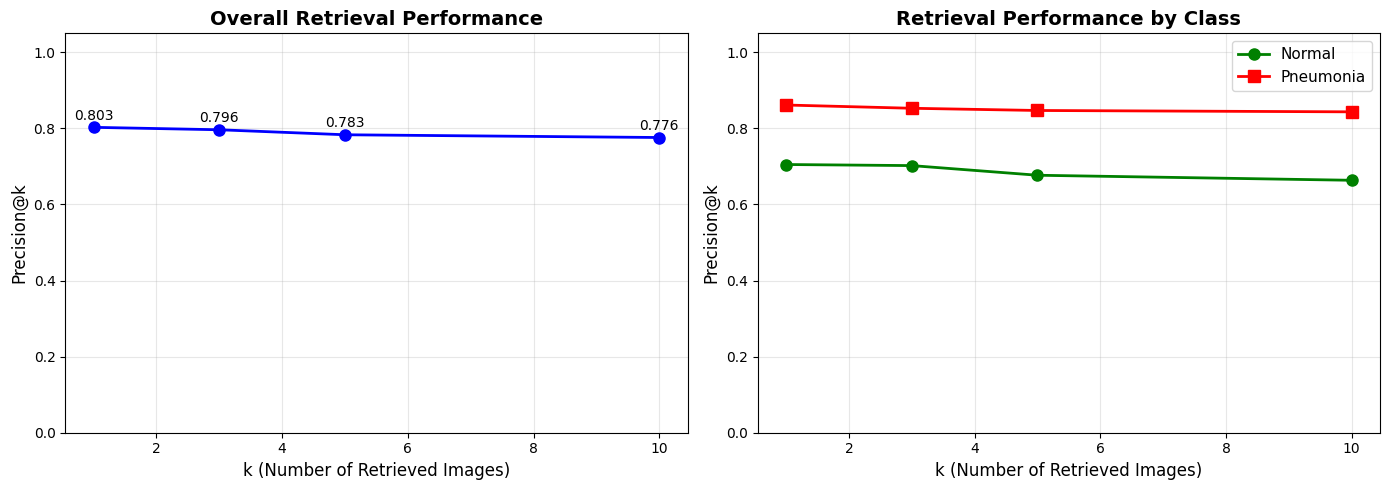

✓ Plot saved as 'task3_precision_at_k.png'


In [14]:
# Plot Precision@k curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall Precision@k
k_list = list(k_values)
avg_precisions = [np.mean(precision_results[k]) for k in k_list]

ax1.plot(k_list, avg_precisions, marker='o', linewidth=2, markersize=8, color='blue')
ax1.set_xlabel('k (Number of Retrieved Images)', fontsize=12)
ax1.set_ylabel('Precision@k', fontsize=12)
ax1.set_title('Overall Retrieval Performance', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_ylim([0, 1.05])

# Add value labels
for k, prec in zip(k_list, avg_precisions):
    ax1.text(k, prec + 0.02, f'{prec:.3f}', ha='center', fontsize=10)

# Precision@k by class
normal_precisions_avg = [np.mean([precision_results[k][i] for i in np.where(all_labels == 0)[0]])
                         for k in k_list]
pneumonia_precisions_avg = [np.mean([precision_results[k][i] for i in np.where(all_labels == 1)[0]])
                            for k in k_list]

ax2.plot(k_list, normal_precisions_avg, marker='o', linewidth=2, markersize=8,
         label='Normal', color='green')
ax2.plot(k_list, pneumonia_precisions_avg, marker='s', linewidth=2, markersize=8,
         label='Pneumonia', color='red')
ax2.set_xlabel('k (Number of Retrieved Images)', fontsize=12)
ax2.set_ylabel('Precision@k', fontsize=12)
ax2.set_title('Retrieval Performance by Class', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('task3_precision_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot saved as 'task3_precision_at_k.png'")

FAILURE CASE ANALYSIS

Found 96 queries with Precision@5 ≤ 0.4

Worst 5 retrieval cases:
1. Image 1: Label=Normal, Precision@5=0.00
2. Image 20: Label=Normal, Precision@5=0.00
3. Image 23: Label=Pneumonia, Precision@5=0.00
4. Image 38: Label=Normal, Precision@5=0.00
5. Image 91: Label=Normal, Precision@5=0.00

Visualizing worst case (Image 1, Precision@5=0.00):


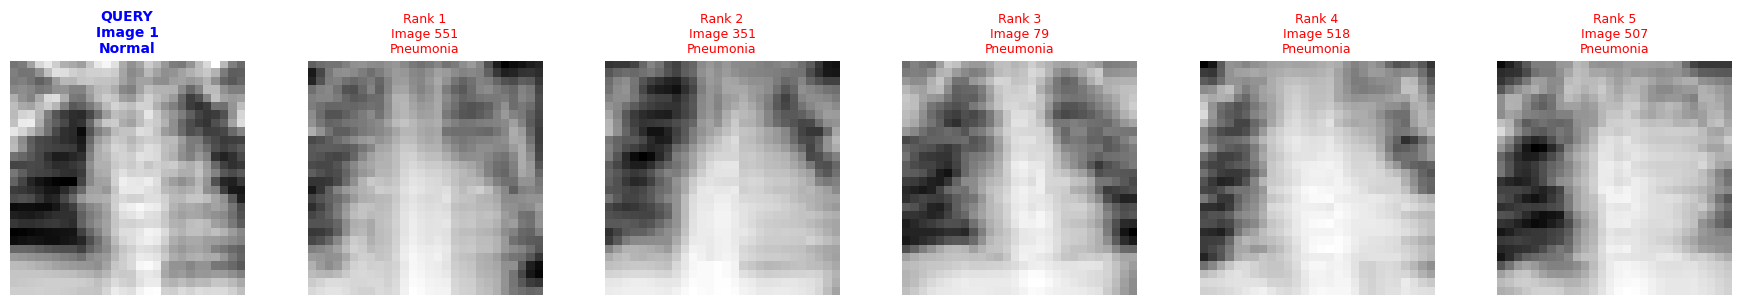


Analysis of failure:
  Query label: Normal
  Retrieved labels: ['Pneumonia', 'Pneumonia', 'Pneumonia', 'Pneumonia', 'Pneumonia']
  Possible reasons:
    - Query image may be atypical or ambiguous
    - Low resolution (28x28) limits discriminative features
    - Class imbalance in dataset


In [15]:
# Find and analyze cases with low retrieval precision
print("="*80)
print("FAILURE CASE ANALYSIS")
print("="*80)

k = 5  # Analyze Precision@5
low_precision_threshold = 0.4

# Find queries with low precision
low_precision_queries = []
for query_idx in range(len(all_images)):
    if precision_results[k][query_idx] <= low_precision_threshold:
        low_precision_queries.append((query_idx, precision_results[k][query_idx]))

print(f"\nFound {len(low_precision_queries)} queries with Precision@{k} ≤ {low_precision_threshold}")

if len(low_precision_queries) > 0:
    # Sort by precision (lowest first)
    low_precision_queries.sort(key=lambda x: x[1])

    print(f"\nWorst 5 retrieval cases:")
    for i, (query_idx, precision) in enumerate(low_precision_queries[:5], 1):
        query_label = all_labels[query_idx]
        print(f"{i}. Image {query_idx}: Label={'Pneumonia' if query_label == 1 else 'Normal'}, "
              f"Precision@{k}={precision:.2f}")

    # Visualize worst case
    if len(low_precision_queries) > 0:
        worst_query_idx, worst_precision = low_precision_queries[0]

        print(f"\nVisualizing worst case (Image {worst_query_idx}, Precision@{k}={worst_precision:.2f}):")

        _, indices = search_similar_images(worst_query_idx, index, embeddings, top_k=k)
        visualize_search_results(worst_query_idx, indices, all_images, all_labels)

        print("\nAnalysis of failure:")
        query_label = all_labels[worst_query_idx]
        retrieved_labels = all_labels[indices]
        print(f"  Query label: {'Pneumonia' if query_label == 1 else 'Normal'}")
        print(f"  Retrieved labels: {['Pneumonia' if l == 1 else 'Normal' for l in retrieved_labels]}")
        print(f"  Possible reasons:")
        print(f"    - Query image may be atypical or ambiguous")
        print(f"    - Low resolution (28x28) limits discriminative features")
        print(f"    - Class imbalance in dataset")
else:
    print("\n✓ No low-precision queries found! Retrieval system performs well.")

RETRIEVAL SYSTEM DEMO

Demonstrating retrieval on 6 sample queries...

Query Image 164: Normal
Precision@5: 1.00

Top 5 retrieved images:
  1. Image 578: Normal (dist=0.042) ✓
  2. Image 77: Normal (dist=0.043) ✓
  3. Image 267: Normal (dist=0.044) ✓
  4. Image 501: Normal (dist=0.044) ✓
  5. Image 471: Normal (dist=0.047) ✓


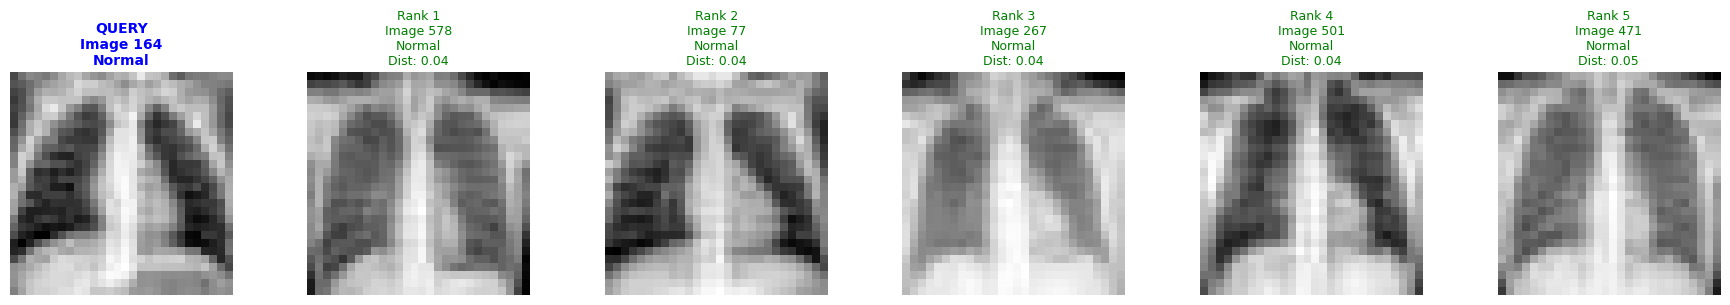


Query Image 541: Normal
Precision@5: 0.80

Top 5 retrieved images:
  1. Image 142: Normal (dist=0.021) ✓
  2. Image 372: Normal (dist=0.042) ✓
  3. Image 272: Pneumonia (dist=0.047) ✗
  4. Image 36: Normal (dist=0.052) ✓
  5. Image 114: Normal (dist=0.056) ✓


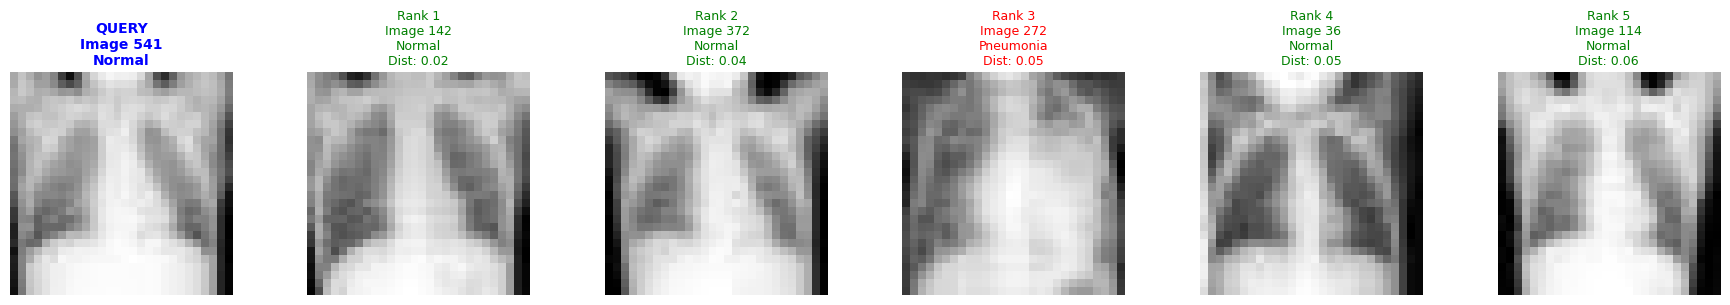


Query Image 475: Normal
Precision@5: 0.60

Top 5 retrieved images:
  1. Image 177: Normal (dist=0.032) ✓
  2. Image 457: Normal (dist=0.035) ✓
  3. Image 178: Pneumonia (dist=0.035) ✗
  4. Image 598: Pneumonia (dist=0.038) ✗
  5. Image 492: Normal (dist=0.038) ✓


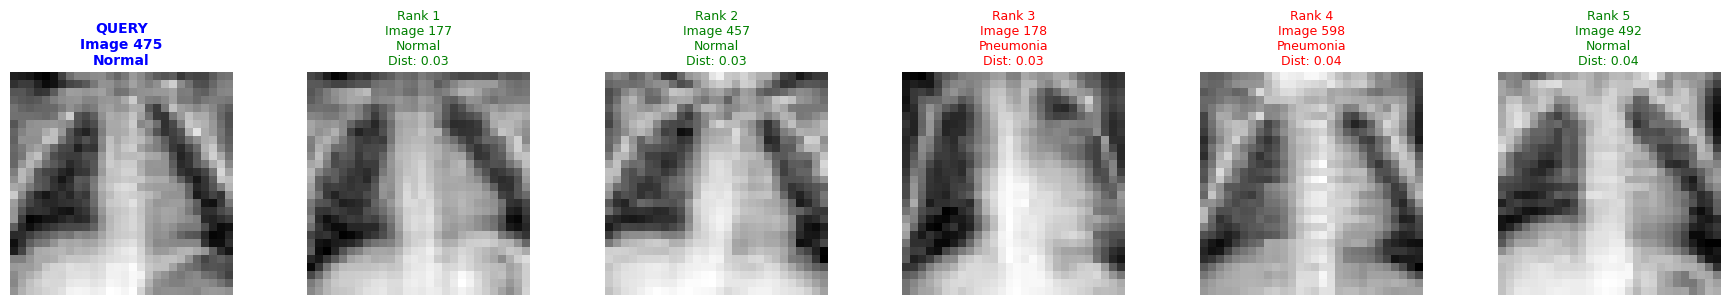


Query Image 397: Pneumonia
Precision@5: 0.80

Top 5 retrieved images:
  1. Image 612: Pneumonia (dist=0.027) ✓
  2. Image 13: Pneumonia (dist=0.028) ✓
  3. Image 33: Pneumonia (dist=0.029) ✓
  4. Image 280: Normal (dist=0.030) ✗
  5. Image 113: Pneumonia (dist=0.030) ✓


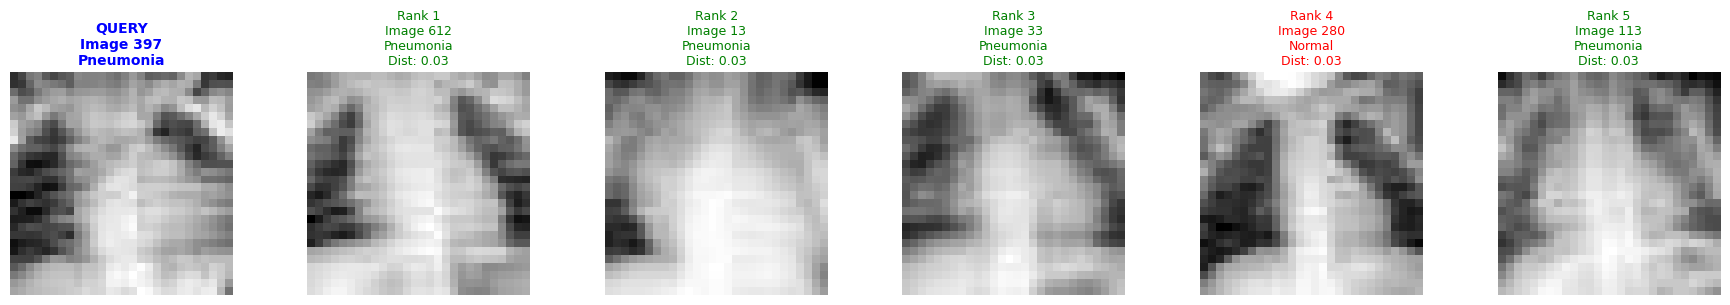


Query Image 400: Pneumonia
Precision@5: 0.60

Top 5 retrieved images:
  1. Image 432: Pneumonia (dist=0.025) ✓
  2. Image 316: Pneumonia (dist=0.032) ✓
  3. Image 574: Pneumonia (dist=0.033) ✓
  4. Image 552: Normal (dist=0.033) ✗
  5. Image 398: Normal (dist=0.037) ✗


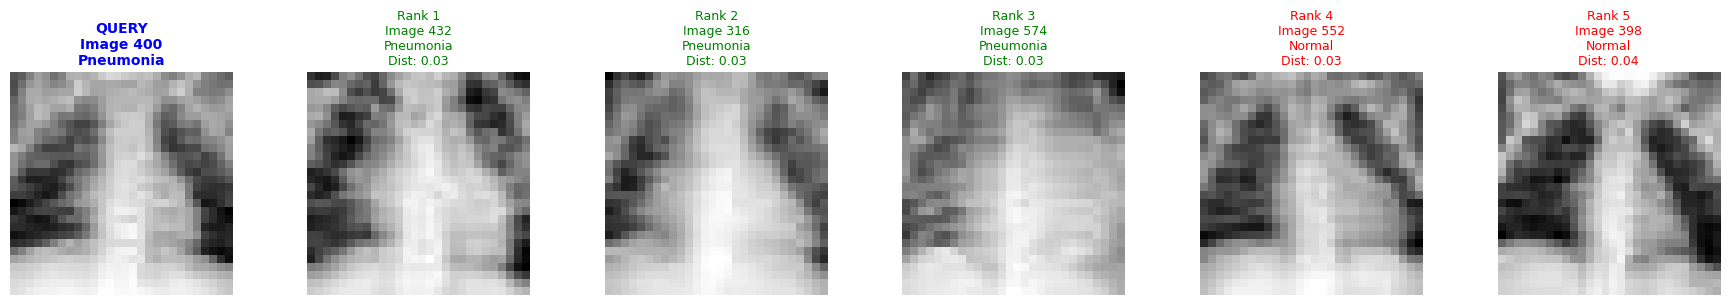


Query Image 346: Pneumonia
Precision@5: 0.80

Top 5 retrieved images:
  1. Image 440: Pneumonia (dist=0.029) ✓
  2. Image 538: Pneumonia (dist=0.029) ✓
  3. Image 356: Normal (dist=0.031) ✗
  4. Image 322: Pneumonia (dist=0.032) ✓
  5. Image 155: Pneumonia (dist=0.032) ✓


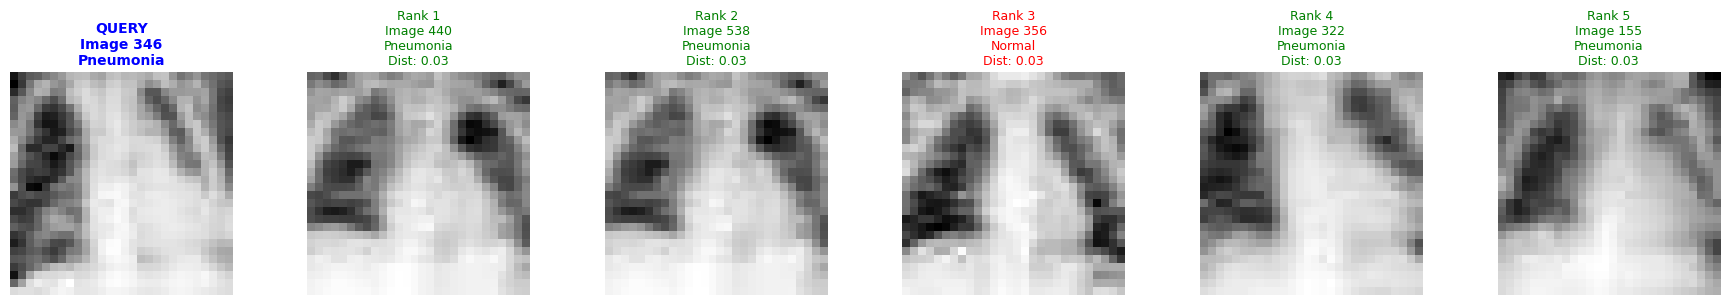

In [16]:
# Interactive retrieval demo
print("="*80)
print("RETRIEVAL SYSTEM DEMO")
print("="*80)

# Select diverse query images
np.random.seed(42)
normal_samples = np.random.choice(np.where(all_labels == 0)[0], 3, replace=False)
pneumonia_samples = np.random.choice(np.where(all_labels == 1)[0], 3, replace=False)
demo_queries = np.concatenate([normal_samples, pneumonia_samples])

print(f"\nDemonstrating retrieval on {len(demo_queries)} sample queries...")

for query_idx in demo_queries:
    query_label = all_labels[query_idx]

    print(f"\n{'='*80}")
    print(f"Query Image {query_idx}: {'Pneumonia' if query_label == 1 else 'Normal'}")
    print('='*80)

    # Retrieve similar images
    distances, indices = search_similar_images(query_idx, index, embeddings, top_k=5)

    # Calculate precision
    precision = calculate_precision_at_k(query_idx, indices, all_labels, k=5)

    print(f"Precision@5: {precision:.2f}")
    print(f"\nTop 5 retrieved images:")
    for rank, (idx, dist) in enumerate(zip(indices, distances), 1):
        retrieved_label = all_labels[idx]
        match = "✓" if retrieved_label == query_label else "✗"
        print(f"  {rank}. Image {idx}: {'Pneumonia' if retrieved_label == 1 else 'Normal'} "
              f"(dist={dist:.3f}) {match}")

    # Visualize
    visualize_search_results(query_idx, indices, all_images, all_labels, distances)

In [17]:
# Save all results
import json

results_summary = {
    "model": model_name,
    "embedding_dimension": int(embed_dim),
    "total_images": int(len(all_images)),
    "index_type": "FAISS Flat (L2)",
    "precision_at_k": {
        f"P@{k}": {
            "overall": float(np.mean(precision_results[k])),
            "std": float(np.std(precision_results[k])),
            "normal": float(np.mean([precision_results[k][i] for i in np.where(all_labels == 0)[0]])),
            "pneumonia": float(np.mean([precision_results[k][i] for i in np.where(all_labels == 1)[0]]))
        }
        for k in k_values
    }
}

# Save as JSON
with open('task3_results.json', 'w') as f:
    json.dump(results_summary, indent=2, fp=f)

print("✓ Results saved to 'task3_results.json'")

# Save detailed results
np.save('task3_precision_results.npy', precision_results)
print("✓ Detailed precision results saved to 'task3_precision_results.npy'")

# Create results text file
with open('task3_retrieval_results.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("TASK 3: SEMANTIC IMAGE RETRIEVAL SYSTEM RESULTS\n")
    f.write("="*80 + "\n\n")

    f.write(f"Model: {model_name}\n")
    f.write(f"Embedding Dimension: {embed_dim}\n")
    f.write(f"Total Images: {len(all_images)}\n")
    f.write(f"Index Type: FAISS Flat (L2)\n\n")

    f.write("="*80 + "\n")
    f.write("PRECISION@K RESULTS\n")
    f.write("="*80 + "\n\n")

    for k in k_values:
        avg_prec = np.mean(precision_results[k])
        std_prec = np.std(precision_results[k])
        f.write(f"Precision@{k}: {avg_prec:.4f} ± {std_prec:.4f}\n")

    f.write("\n" + "="*80 + "\n")
    f.write("PRECISION@K BY CLASS\n")
    f.write("="*80 + "\n\n")

    for k in k_values:
        normal_prec = np.mean([precision_results[k][i] for i in np.where(all_labels == 0)[0]])
        pneumonia_prec = np.mean([precision_results[k][i] for i in np.where(all_labels == 1)[0]])
        f.write(f"Precision@{k}:\n")
        f.write(f"  Normal:    {normal_prec:.4f}\n")
        f.write(f"  Pneumonia: {pneumonia_prec:.4f}\n\n")

print("✓ Results saved to 'task3_retrieval_results.txt'")

✓ Results saved to 'task3_results.json'
✓ Detailed precision results saved to 'task3_precision_results.npy'
✓ Results saved to 'task3_retrieval_results.txt'


In [18]:
# Download all generated files
from google.colab import files

print("Preparing files for download...")

# List of files to download
download_files = [
    'image_embeddings.npy',
    'image_labels.npy',
    'image_embeddings.index',
    'task3_results.json',
    'task3_precision_results.npy',
    'task3_retrieval_results.txt',
    'task3_precision_at_k.png'
]

for filename in download_files:
    try:
        files.download(filename)
        print(f"✓ Downloaded: {filename}")
    except Exception as e:
        print(f"✗ Could not download {filename}: {e}")

print("\n✓ All files ready for download!")

Preparing files for download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: image_embeddings.npy


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloaded: task3_retrieval_results.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: task3_precision_at_k.png

✓ All files ready for download!


In [19]:
print("\n" + "="*80)
print("TASK 3 COMPLETION SUMMARY")
print("="*80)

print(f"\n✓ Embedding Model: {model_name}")
print(f"✓ Embedding Dimension: {embed_dim}")
print(f"✓ Total Images Indexed: {len(all_images)}")
print(f"✓ Vector Database: FAISS (Flat L2)")

print(f"\n✓ Image-to-Image Search: Implemented")
print(f"✓ Text-to-Image Search: {'Implemented' if processor else 'Not implemented'}")

print(f"\n✓ Evaluation Metrics:")
for k in k_values:
    avg_prec = np.mean(precision_results[k])
    print(f"  Precision@{k}: {avg_prec:.4f}")

print(f"\n✓ Visualizations Created:")
print(f"  - Precision@k curves")
print(f"  - Sample retrieval results")
print(f"  - Failure case analysis")

print(f"\n✓ Files Generated:")
print(f"  - image_embeddings.npy (embeddings)")
print(f"  - image_embeddings.index (FAISS index)")
print(f"  - task3_results.json (summary)")
print(f"  - task3_retrieval_results.txt (detailed results)")
print(f"  - task3_precision_at_k.png (visualization)")

print("="*80)


TASK 3 COMPLETION SUMMARY

✓ Embedding Model: openai/clip-vit-base-patch32
✓ Embedding Dimension: 512
✓ Total Images Indexed: 624
✓ Vector Database: FAISS (Flat L2)

✓ Image-to-Image Search: Implemented
✓ Text-to-Image Search: Implemented

✓ Evaluation Metrics:
  Precision@1: 0.8029
  Precision@3: 0.7965
  Precision@5: 0.7833
  Precision@10: 0.7761

✓ Visualizations Created:
  - Precision@k curves
  - Sample retrieval results
  - Failure case analysis

✓ Files Generated:
  - image_embeddings.npy (embeddings)
  - image_embeddings.index (FAISS index)
  - task3_results.json (summary)
  - task3_retrieval_results.txt (detailed results)
  - task3_precision_at_k.png (visualization)
